# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [ ]:
!pip install datasets

In [1]:
from datasets import load_dataset
sst2 = load_dataset("SetFit/sst2")

data_train = sst2['train']
data_val = sst2['validation']

c:\Users\guyil\OneDrive\Desktop\Programing\Courses\nebius\AI_Performance_Engineering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\guyil\OneDrive\Desktop\Programing\Courses\nebius\AI_Performance_Engineering\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\guyil\.cache\huggingface\hub\datasets--SetFit--sst2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you 

**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [6]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



Map: 100%|██████████| 872/872 [00:00<00:00, 43482.38 examples/s]


In [7]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [8]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [9]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000
Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [ ]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch (70 points)**

#### **Task 1.1 - Binary vs. Softmax Formulation and Numerical Stability of Cross-Entropy Loss (10 points)**



In this task, you will explore two ways to formulate the loss function for a classification problem and understand why numerical stability is important.

**a. Binary formulation**

   In the binary formulation, the model has:

   * a single output
   * sigmoid activation
   * binary cross-entropy loss

   This produces a probability: P(y=1|x)
   
   A prediction is then obtained using a threshold:
   * predict class 1 if p>0.5
   * otherwise predict class 0

   For binary logistic regression, the standard loss function is the **binary cross-entropy loss**:

   $L= -\frac{1}{N}\sum_{i=1}^N[y_ilog(\hat{y_i})+(1-y_i)log(1-\hat{y_i})]$

   where $\hat{y_i}$ is the predicted probability after applying sigmoid.

   Since this loss contains both: $log(\hat{y})$ and $log(1-\hat{y})$ , numerical problems may appear if $\hat{y_i}$ becomes extremely close to 0 or 1.

   A stable implementation should therefore clamp the predicted probabilities:
```
y_pred = # SIGMOID(LOGITS)
epsilon = 1e-15  
y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
log_loss = # <SMTH FROM y_pred>
```

**Note:** the threshold 0.5 is used only to convert probabilities into class predictions for evaluation.
It must not be used inside the loss function.

**b. Softmax formulation**

  Now, we will reformulate the same problem as a 2-class classification problem using softmax (This formulation is more general and can also be used for more than 2 classes.).
  
  **Step 1 — Convert labels to one-hot encoding**
  
  In our dataset the labels are either 1 or 0 (i.e positive or negetive). To use softmax will require us to convert the labels into a one-hot representation:
  * class 0 ---> [1,0]
  * class 1 ---> [0,1]

  Now our model will output 2 outputs instead of 1 and we will require to apply softmax to get the probability of class 0 vs. class 1.

  **Step 2 - Implementing softmax and log-loss**
  
   This can be implemented in two ways:

  1. **Naive version:**
  
     Given logits z = [$z_1,z_2,...,z_k$]

     softmax($z_i$) = $\frac{\exp(z_i)}{\sum_j\exp(z_j)}$


  2. **Stable version:**

     softmax($z_i$) = $\frac{\exp(z_i-max(z))}{\sum_j\exp(z_j-max(z))}$

   Than the cross entropy loss for the true class y is :

   **L = -log(softmax($z_y$))**

   or equivalently, for one-hot labels:
   
   **$L= -\sum_{c=1}^Ky_clog(\hat{y_c})$**

**Task**

A. Conceptual questions

For both the binary and softmax formulations, explain:

* Why do we need numerical stability? Where can the naive implementation fail?
* Why does the stability transformation not change the final softmax probabilities?
* Why does this transformation improve numerical stability?

B. Implementation
1. Implement a binary cross-entropy loss function for the binary formulation.
2. Make sure your implementation is numerically stable.




In [59]:
import torch

def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute the binary cross-entropy loss for a logistic regression model.
    """
    epsilon = 1e-15
    # Keep values between epsilon and 1-epsilon
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
    # Calculate binary cross entropy formula
    loss = - (y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    # Return the average loss for the batch
    return torch.mean(loss)

####**Task 1.2. - Implement Logistic Regression in PyTorch (10 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [21]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        # TODO:
        # Initialize the weight vector `w` based on the `init` argument
        # Make sure:
        # - shape is (n_features, 1)
        # - random initialization uses SMALL values (important!)
        # - if init is a tensor, clone + detach it

        if init == "zeros":
            w = torch.zeros((n_features, 1), dtype=torch.float32)

        elif init == "random":
            w = torch.randn((n_features, 1), dtype=torch.float32) * 0.01

        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().float()

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        # TODO:
        # Wrap weights and bias using nn.Parameter
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1, dtype=torch.float32))

    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        # TODO:
        logits = x @ self.w + self.b
        
        #implement sigmoid function
        probs = 1 / (1 + torch.exp(-logits))

        return probs

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """

        # TODO:
        probs = self.forward(x)
        preds = (probs >= 0.5).float()

        return preds

####**Task 1.3 - Train Logistic Regression with SGD Using Your Previous Implementations (10 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use:

1. your LogisticRegression class from Task 1.2
2. your binary_cross_entropy_loss function from Task 1.1

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [22]:
#implement f1score calculation
def f1_score(y_true, y_pred):
    """
    Compute the F1 score for binary classification.

    Parameters
    ----------
    y_true : np.array
        True binary labels (0 or 1)
    y_pred : np.array
        Predicted binary labels (0 or 1)

    Returns
    -------
    f1 : float
        F1 score value
    """
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp + 1e-15)
    recall = tp / (tp + fn + 1e-15)

    f1 = 2 * (precision * recall) / (precision + recall + 1e-15)
    return f1

def accuracy(y_true, y_pred):
    """
    Compute the accuracy for binary classification.

    Parameters
    ----------
    y_true : np.array
        True binary labels (0 or 1)
    y_pred : np.array
        Predicted binary labels (0 or 1)

    Returns
    -------
    acc : float
        Accuracy value
    """
    acc = np.mean(y_true == y_pred)
    return acc

In [114]:
import torch

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty='none',          # For Task 1.5 : options: 'none', 'l1', 'l2'
    reg_lambda=torch.tensor(0.0),          # For Task 1.5
    metric='accuracy',
    print_metrics=False
):
    """
    Train a logistic regression model using mini-batch SGD.

    You must use:
    - LogisticRegression
    - binary_cross_entropy_loss

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val     : validation data
    lr : float
        Learning rate
    epochs : int
        Number of passes over the training data
    batch_size : int
        Mini-batch size
    init : str
        Weight initialization passed to LogisticRegression
    penalty : str
        'none', 'l1', or 'l2'
    reg_lambda : float
        Regularization strength
    metric : str
        Evaluation metric to report ('accuracy' , 'f1' or other)
    print_metrics : bool
        Whether to print metrics after each epoch

    Returns
    -------
    w : numpy.ndarray
        Final learned weights
    b : numpy.ndarray
        Final learned bias
    history : list
        Batch-wise history of parameter values
    epoch_log : list
        Per-epoch logs (loss + metrics)
    """


    # 1. Convert data to tensors

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    n_samples, n_features = X_train_tensor.shape


    # 2. Initialize model

    model = LogisticRegression(n_features=n_features, init=init)


    # 3. Create optimizer

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)


    # 4. Create logs

    history = []      # save w, b after each batch update
    epoch_log = []    # save epoch-level loss and metrics


    # 5. Training loop

    for epoch in range(epochs):

        # TODO:
        # Shuffle the training data at the beginning of each epoch
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            # TODO:
            # Select mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # TODO:
            # Forward pass
            y_pred = model(X_batch)

            # TODO:
            # Compute non-regularized BCE loss using your function
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # TODO in task 1.5:
            # Add regularization if needed
            # penalty == 'l1'  -> reg_lambda * ||w||_1
            # penalty == 'l2'  -> reg_lambda * ||w||_2^2
            # penalty == 'none' -> no regularization
            if penalty == 'l1':
               reg_term = reg_lambda * torch.sum(torch.abs(model.w))
            elif penalty == 'l2':
               reg_term = reg_lambda * torch.sum(model.w ** 2)
            else:
               reg_term = 0.0

            loss = data_loss + reg_term

            # TODO:
            # Backward pass and optimization step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # TODO:
            # Save current parameter values after the batch update
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone(),
                'b': model.b.detach().clone()
            })


        # 6. Epoch-level evaluation

        with torch.no_grad():

            # TODO:
            # Compute probabilities on full train/val sets
            y_pred_train = model.forward(X_train_tensor)
            y_pred_val = model.forward(X_val_tensor)

            # TODO:
            # Compute NON-regularized train loss and val loss
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            # TODO:
            # Convert probabilities to binary predictions
            y_hat_train = model.predict(X_train_tensor)
            y_hat_val = model.predict(X_val_tensor)

            # TODO:
            # Compute evaluation metric
            if metric == 'f1':
                train_metric = f1_score(y_train_tensor.numpy(), y_hat_train.numpy())
                val_metric = f1_score(y_val_tensor.numpy(), y_hat_val.numpy())
            else:
                train_metric = accuracy(y_train_tensor.numpy(), y_hat_train.numpy())
                val_metric = accuracy(y_val_tensor.numpy(), y_hat_val.numpy())

        epoch_log.append({
            'epoch': epoch,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().numpy(), model.b.detach().numpy(), history, epoch_log

####**Task 1.4 - Experiments (20 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

exp_grid = {
    'lr': [0.01, 0.03, 0.1, 0.3, 1.0],
    'batch_size': [50, 100, 200]
}

results_list = []

for lr in exp_grid['lr']:
    for batch_size in exp_grid['batch_size']:
        print(f"Running experiment with lr={lr}, batch_size={batch_size}")
        w, b, history, epoch_log = sgd_logistic_regression(
            X_train, y_train,
            X_val, y_val,
            lr=lr,
            epochs=20,
            batch_size=batch_size,
            init="random",
            penalty='none',
            reg_lambda=0.0,
            metric='f1',
            print_metrics=False
        )
        final_epoch = epoch_log[-1]
        results_list.append({
            'lr': lr,
            'batch_size': batch_size,
            'train_loss': final_epoch['train_loss'],
            'val_loss': final_epoch['val_loss'],
            'train_f1': final_epoch['train_metric'],
            'val_f1': final_epoch['val_metric']
        })

results = pd.DataFrame(results_list)

Running experiment with lr=0.01, batch_size=50
Running experiment with lr=0.01, batch_size=100
Running experiment with lr=0.01, batch_size=200
Running experiment with lr=0.03, batch_size=50
Running experiment with lr=0.03, batch_size=100
Running experiment with lr=0.03, batch_size=200
Running experiment with lr=0.1, batch_size=50
Running experiment with lr=0.1, batch_size=100
Running experiment with lr=0.1, batch_size=200
Running experiment with lr=0.3, batch_size=50
Running experiment with lr=0.3, batch_size=100
Running experiment with lr=0.3, batch_size=200
Running experiment with lr=1.0, batch_size=50
Running experiment with lr=1.0, batch_size=100
Running experiment with lr=1.0, batch_size=200


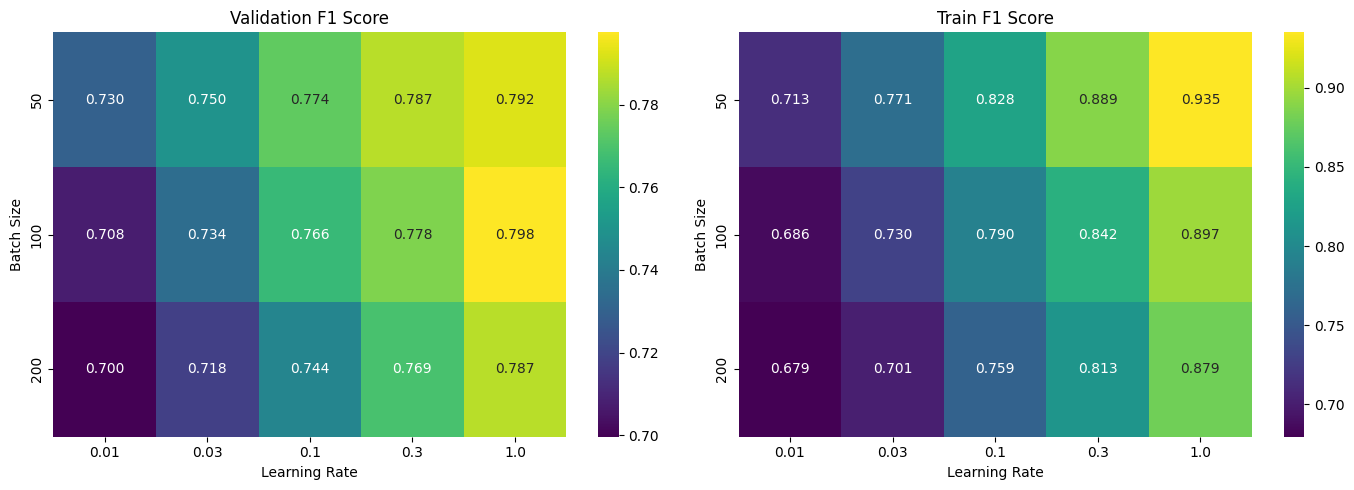

In [71]:
# Create heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pivot for heatmap: rows=batch_size, cols=lr, values=f1
pivot_val_f1 = results.pivot(index='batch_size', columns='lr', values='val_f1')
sns.heatmap(pivot_val_f1, annot=True, fmt='.3f', cmap='viridis', ax=axes[0])
axes[0].set_title('Validation F1 Score')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Batch Size')

# Pivot for train accuracy
pivot_train_f1 = results.pivot(index='batch_size', columns='lr', values='train_f1')
sns.heatmap(pivot_train_f1, annot=True, fmt='.3f', cmap='viridis', ax=axes[1])
axes[1].set_title('Train F1 Score')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Batch Size')

plt.tight_layout()
plt.show()

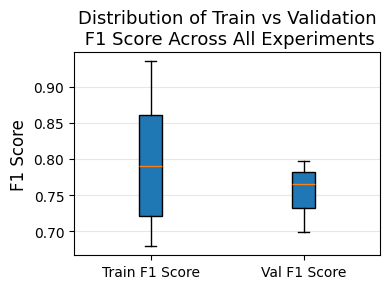

In [72]:
# Create boxplot comparing train and validation f1 distributions
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Prepare data for boxplot
data_to_plot = [results['train_f1'], results['val_f1']]

bp = ax.boxplot(data_to_plot, patch_artist=True)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Distribution of Train vs Validation\n F1 Score Across All Experiments', fontsize=13)
ax.set_xticklabels(['Train F1 Score', 'Val F1 Score'])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Analysis:

#### Learning rate (lr):

- Convergence speed: higher lr means bigger parameter updates each step, so loss/F1 changes faster per epoch.
- Stability: very high lr can overshoot the minimum and cause oscillation/divergence, but in our tested range it stayed stable, which means updates were still within a safe step size.
- Final performance: with only 20 epochs, larger lr reached a better region of the loss surface in time. small lr likely under-trained (did not move far enough yet).

#### Batch size

- Convergence speed: smaller batches converge much faster in terms of the number of epochs. Because weights are updated after every small chunk of data, the model performs many more "steps" per epoch compared to a large batch size.
- Stability: larger batches average gradients over more samples, so updates are smoother and less noisy; smaller batches are noisier but can still be stable if lr is not too large.
- Final performance: medium/small batches often generalize better because noise acts like implicit regularization; very large batches can converge to sharper minima and give weaker val F1 in your results.

Bottom line: in this experiment, lr had the strongest effect, and lr=1.0 with batch_size=100 gave the best validation result.

####**Task 1.5 — L1 Regularization and Sparsity (20 points)**



In this task, you will extend your implementation from Task 1.2 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

In [115]:
w_zeros, b_zeros, hist_zeros, log_zeros = sgd_logistic_regression(
    X_train, y_train, X_val, y_val, init="zeros", lr=0.1, batch_size=100, epochs=20
)

w_rand, b_rand, hist_rand, log_rand = sgd_logistic_regression(
    X_train, y_train, X_val, y_val, init="random", lr=0.1, batch_size=100, epochs=20
)

# Sparsity check
thresh = 1e-7
print("Zeros init — near-zero weights:", np.sum(np.abs(w_zeros) < thresh))
print("Random init — near-zero weights:", np.sum(np.abs(w_rand) < thresh))

# Check for NaNs (stability)
print("NaN in zeros weights:", np.any(np.isnan(w_zeros)))
print("NaN in random weights:", np.any(np.isnan(w_rand)))

Zeros init — near-zero weights: 0
Random init — near-zero weights: 0
NaN in zeros weights: False
NaN in random weights: False


In [124]:
lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
inits = ["zeros", "random"]
results = []

for lam in lambdas:
    for init in inits:
        print(f"Running experiment with lambda={lam}, init={init}")
        w, b, history, log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            lr=0.1, batch_size=100, epochs=100,
            penalty='l1', reg_lambda=lam,
            metric='accuracy', init=init
        )
        final = log[-1]
        nonzero = np.sum(np.abs(w) > 1e-7)
        results.append({
            'lambda': lam,
            'init': init,
            'train_acc': final['train_metric'],
            'val_acc': final['val_metric'],
            'nonzero_weights': nonzero,
            'w': w,
            'history': history
        })

Running experiment with lambda=0, init=zeros
Running experiment with lambda=0, init=random
Running experiment with lambda=0.0001, init=zeros
Running experiment with lambda=0.0001, init=random
Running experiment with lambda=0.001, init=zeros
Running experiment with lambda=0.001, init=random
Running experiment with lambda=0.01, init=zeros
Running experiment with lambda=0.01, init=random
Running experiment with lambda=0.1, init=zeros
Running experiment with lambda=0.1, init=random


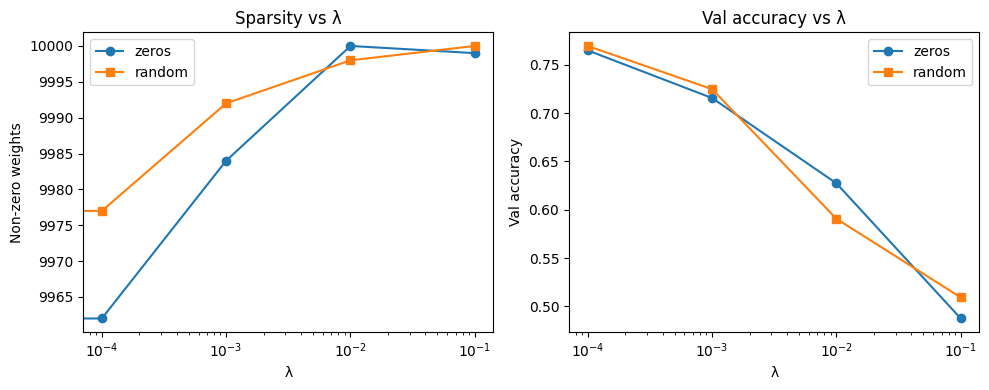

In [125]:
df = pd.DataFrame(results)

zeros_df = df[df['init'] == 'zeros']
random_df = df[df['init'] == 'random']

# Non-zero weights vs lambda (one line per init)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(lambdas, zeros_df['nonzero_weights'].values, marker='o', label='zeros')
plt.plot(lambdas, random_df['nonzero_weights'].values, marker='s', label='random')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Non-zero weights')
plt.title('Sparsity vs λ')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lambdas[1:], zeros_df[zeros_df['lambda'] > 0]['val_acc'].values, marker='o', label='zeros')
plt.plot(lambdas[1:], random_df[random_df['lambda'] > 0]['val_acc'].values, marker='s', label='random')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Val accuracy')
plt.title('Val accuracy vs λ')
plt.legend()

plt.tight_layout()
plt.show()

Running experiment with lambda=0, init=zeros
Running experiment with lambda=0, init=random
Running experiment with lambda=0.0001, init=zeros
Running experiment with lambda=0.0001, init=random
Running experiment with lambda=0.001, init=zeros
Running experiment with lambda=0.001, init=random
Running experiment with lambda=0.01, init=zeros
Running experiment with lambda=0.01, init=random
Running experiment with lambda=0.1, init=zeros
Running experiment with lambda=0.1, init=random


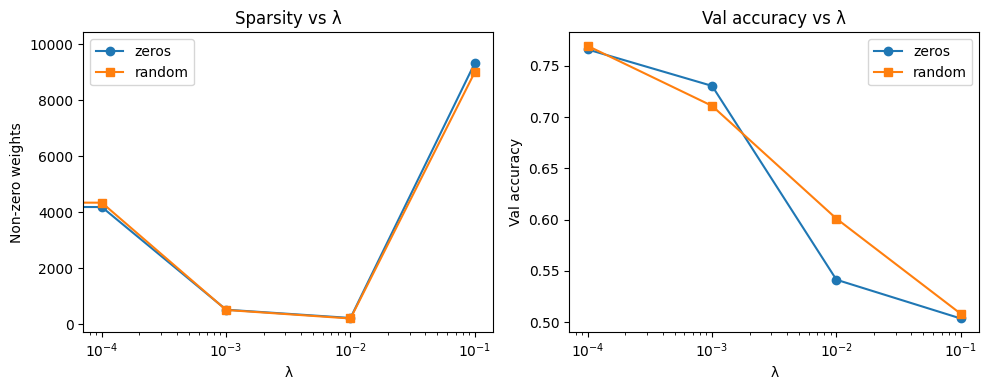

In [126]:
lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
inits = ["zeros", "random"]
results = []

for lam in lambdas:
    for init in inits:
        print(f"Running experiment with lambda={lam}, init={init}")
        w, b, history, log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            lr=0.1, batch_size=100, epochs=100,
            penalty='l1', reg_lambda=lam,
            metric='accuracy', init=init
        )
        final = log[-1]
        nonzero = np.sum(np.abs(w) > 1e-3)
        results.append({
            'lambda': lam,
            'init': init,
            'train_acc': final['train_metric'],
            'val_acc': final['val_metric'],
            'nonzero_weights': nonzero,
            'w': w,
            'history': history
        })
df = pd.DataFrame(results)

zeros_df = df[df['init'] == 'zeros']
random_df = df[df['init'] == 'random']

# Non-zero weights vs lambda (one line per init)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(lambdas, zeros_df['nonzero_weights'].values, marker='o', label='zeros')
plt.plot(lambdas, random_df['nonzero_weights'].values, marker='s', label='random')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Non-zero weights')
plt.title('Sparsity vs λ')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lambdas[1:], zeros_df[zeros_df['lambda'] > 0]['val_acc'].values, marker='o', label='zeros')
plt.plot(lambdas[1:], random_df[random_df['lambda'] > 0]['val_acc'].values, marker='s', label='random')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Val accuracy')
plt.title('Val accuracy vs λ')
plt.legend()

plt.tight_layout()
plt.show()

We compared two weight initialization strategies (zeros and random) across a range of L1 regularization strengths (0, 1e-4, 1e-3, 1e-2, 1e-1). As expected, increasing λ induces greater sparsity — at λ=1e-3 with a tolerance of 1e-3, roughly 96% of the 10,000 features are effectively eliminated, while validation accuracy remains reasonable at ~72%. The two initialization strategies produce nearly identical results.
However, when using a stricter tolerance of 1e-7, virtually no weights are eliminated across all λ values — nearly all 10,000 features remain "non-zero" even at strong regularization. This reveals an important distinction: SGD with L1 does not produce true zeros, only pushing weights toward zero without ever guaranteeing they reach it. The sparsity we observe at tolerance 1e-3 is therefore threshold-dependent, weights are small but not zero, and the choice of tolerance dramatically changes the picture.

At λ=0.1, an additional failure mode appears: rather than producing the most zeros as one would theoretically expect, the regularization step of `lr · λ = 0.01` per update is large enough that small weights overshoot zero and flip sign every step, oscillating rather than converging.

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (30 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [141]:
import torch
import matplotlib.pyplot as plt

# Works for both theta.shape == (2,) and theta.shape == (..., 2)
def bowl(theta):
    x = theta[..., 0]
    y = theta[..., 1]
    return x**2 + 2 * y**2

def camel(theta):
    x = theta[..., 0]
    y = theta[..., 1]
    return (4 - 2.1 * x**2 + x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_trajectories_camel_log(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)  # (400, 400, 2)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()  # (400, 400)

    # signed log transform (safe for negatives)
    Z_plot = np.sign(Z) * np.log1p(np.abs(Z))

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z_plot, levels=30)

    for name, (trajectory, _) in results.items():
        plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', markersize=2, label=name)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [178]:
def gradient_descent(f, theta0, lr=0.001, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            theta -= lr * theta.grad

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            v = beta * v + (1 - beta) * theta.grad
            theta -= lr * v

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    G = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            G = G + theta.grad ** 2
            theta -= lr / (torch.sqrt(G) + eps) * theta.grad

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


def adam(f, theta0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    m = torch.zeros_like(theta)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(1, n_steps + 1):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            m = beta1 * m + (1 - beta1) * theta.grad
            v = beta2 * v + (1 - beta2) * theta.grad ** 2

            m_hat = m / (1 - beta1 ** step)
            v_hat = v / (1 - beta2 ** step)

            theta -= lr * m_hat / (torch.sqrt(v_hat) + eps)

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


# Run experiments
theta0 = torch.tensor([-2, -1.5])

results_bowl = {
    "GD":       gradient_descent(bowl, theta0, lr=0.01),
    "Momentum": momentum(bowl, theta0, lr=0.01, beta=0.9),
    "AdaGrad":  adagrad(bowl, theta0, lr=0.1),
    "Adam":     adam(bowl, theta0, lr=0.01)
}

results_camel = {
    "GD":       gradient_descent(camel, theta0, lr=0.01),
    "Momentum": momentum(camel, theta0, lr=0.1, beta=0.9),
    "AdaGrad":  adagrad(camel, theta0, lr=0.1),
    "Adam":     adam(camel, theta0, lr=0.1)
}

C:\Users\guyil\AppData\Local\Temp\ipykernel_5996\1048489726.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
C:\Users\guyil\AppData\Local\Temp\ipykernel_5996\1048489726.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
C:\Users\guyil\AppData\Local\Temp\ipykernel_5996\1048489726.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=Tr

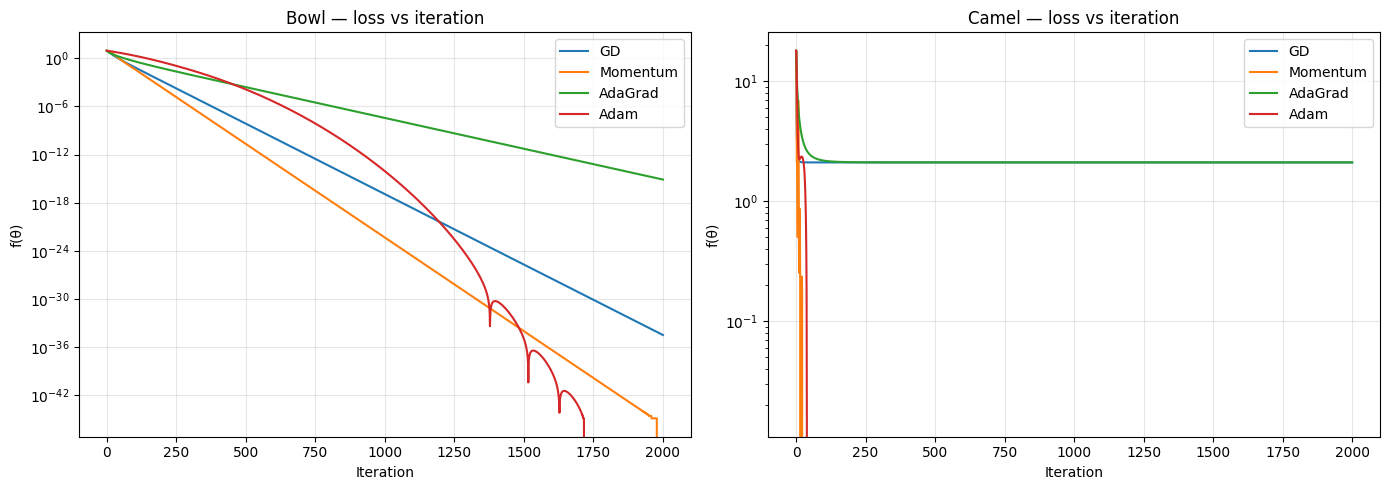

In [179]:
# 1. Function value vs iteration number

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (results, fname) in zip(axes, [(results_bowl, "Bowl"), (results_camel, "Camel")]):
    for name, (trajectory, values) in results.items():
        ax.plot(values, label=name)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("f(θ)")
    ax.set_title(f"{fname} — loss vs iteration")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

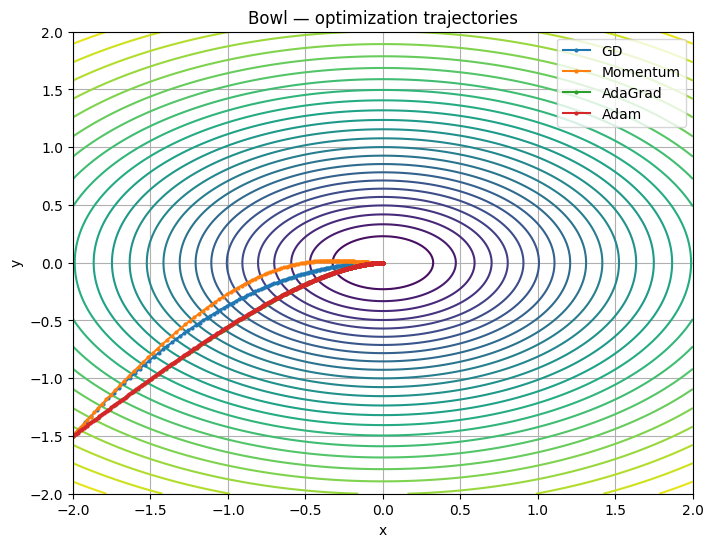

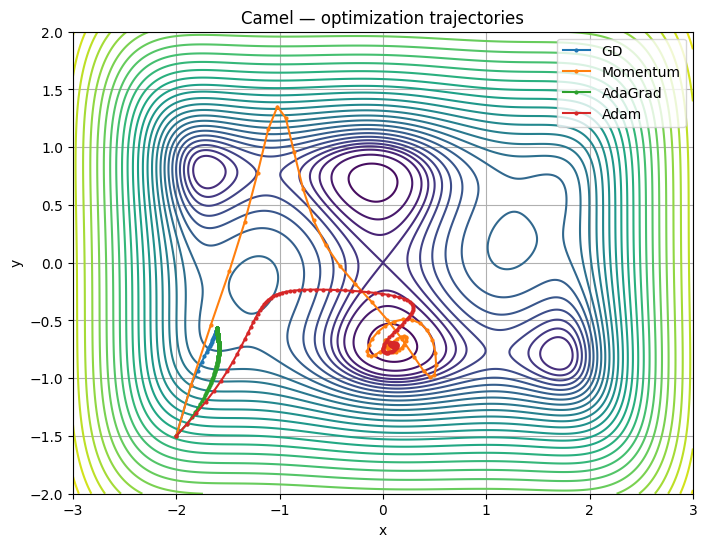

Saved: bowl_trajectories.gif
Saved: camel_trajectories.gif


In [181]:

# 2. Optimization trajectories

plot_trajectories_camel_log(
    bowl,
    results_bowl,
    xlim=(-2, 2), ylim=(-2, 2),
    title="Bowl — optimization trajectories"
)

plot_trajectories_camel_log(
    camel,
    results_camel,
    xlim=(-3, 3), ylim=(-2, 2),
    title="Camel — optimization trajectories"
)


# 3. (Bonus) Animated GIF for camel trajectories

from matplotlib.animation import FuncAnimation, PillowWriter

def animate_trajectories(f, results, xlim=(-3, 3), ylim=(-2, 2),
                         title="Optimization Trajectories", filename="trajectory.gif"):

    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)
    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()
    Z_plot = np.sign(Z) * np.log1p(np.abs(Z))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X, Y, Z_plot, levels=30, cmap="viridis", alpha=0.6)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    colors = plt.cm.tab10.colors
    lines = {}
    dots  = {}
    for i, name in enumerate(results):
        line, = ax.plot([], [], color=colors[i], lw=1.5, label=name)
        dot,  = ax.plot([], [], color=colors[i], marker='o', markersize=5)
        lines[name] = line
        dots[name]  = dot

    ax.legend()

    # find longest trajectory
    max_steps = max(len(traj) for traj, _ in results.values())
    # only render every n-th frame to keep gif size reasonable
    step_size = max(1, max_steps // 200)
    frames = list(range(0, max_steps, step_size))

    def update(frame):
        for name, (trajectory, _) in results.items():
            t = min(frame, len(trajectory) - 1)
            xs = trajectory[:t+1, 0].numpy()
            ys = trajectory[:t+1, 1].numpy()
            lines[name].set_data(xs, ys)
            dots[name].set_data([xs[-1]], [ys[-1]])
        return list(lines.values()) + list(dots.values())

    anim = FuncAnimation(fig, update, frames=frames, blit=True)
    anim.save(filename, writer=PillowWriter(fps=30))
    plt.close()
    print(f"Saved: {filename}")


animate_trajectories(
    bowl, results_bowl,
    xlim=(-2, 2), ylim=(-2, 2),
    title="Bowl — animated trajectories",
    filename="bowl_trajectories.gif"
)

animate_trajectories(
    camel, results_camel,
    xlim=(-3, 3), ylim=(-2, 2),
    title="Camel — animated trajectories",
    filename="camel_trajectories.gif"
)

On the convex bowl, Momentum converges fastest, reaching near-zero loss by around iteration 1800, with Adam close behind despite showing characteristic oscillations (the spikes in the loss curve) before converging aggressively. Plain GD converges steadily but slowly, and AdaGrad is the clear laggard — its accumulation of squared gradients causes the effective learning rate to decay too aggressively over time, slowing progress significantly on a simple quadratic function. All four optimizers do find the global minimum on the bowl, as expected for a convex function, the differences are purely in speed.

On the camel function, with lr=0.001, all optimizers get trapped in the same local minimum in the bottom-left basin, producing nearly identical trajectories and confirming that a small learning rate is too timid to escape the initial point. With lr=0.1, the trajectories diverge: Momentum overshoots wildly, bouncing all the way up to y≈1.3 before eventually settling into a one the global minimums, illustrating how accumulated velocity can cause dangerous overshooting on non-convex landscapes. Adam spirals into the same global minimum, but does so with visible oscillations before stabilizing. AdaGrad takes a short cautious path and settles into the nearby local minimum. This confirms that no optimizer reliably finds the global minimum — the outcome depends heavily on both the starting point and the learning rate.

The same hyperparameters do not transfer equally between the two functions. A learning rate that works well on the smooth bowl (lr=0.001) is far too conservative for the camel, where the complex landscape requires larger steps to escape local basins. Conversely, lr=0.1 destabilizes Momentum on the camel while being perfectly manageable on the bowl. This highlights the key practical advantage of Adam: its adaptive per-parameter scaling makes it the most robust across both landscapes, requiring less manual tuning than plain GD or Momentum. AdaGrad's learning rate decay, while helpful in sparse gradient settings, proves too aggressive here, causing it to stall before reaching good minima on both functions.

Compared to plain gradient descent, the three advanced optimizers each address a distinct weakness. Momentum accelerates convergence by accumulating velocity in consistent gradient directions, allowing it to move faster through flat regions and dampen oscillations — explaining why it outpaces GD on the bowl despite using the same learning rate. AdaGrad adapts the step size per parameter, which removes the need to manually balance dimensions with different gradient scales, though its monotonically decaying learning rate eventually causes it to stall. Adam combines both benefits — momentum for acceleration and adaptive scaling for robustness — while fixing AdaGrad's decay problem using exponential moving averages, making it the most practical default when no prior knowledge about the loss landscape is available.

### **Knowledge Bonus.** An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent



The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$